## Contents

1. [Capon/MVDR Fundamentals](#capon-mvdr-fundamentals)
2. [Capon/MVDR Performance](#capon-mvdr-performance)
   1. [Forward–Backward Averaging and Diagonal Loading](#forward-backward-averaging-and-diagonal-loading)
   2. [Angular Resolution and Model Mismatch](#angular-resolution-and-model-mismatch)

<a id="capon-mvdr-fundamentals"></a>

## Capon/MVDR Fundamentals

The Capon, or Minimum Variance Distortionless Response (MVDR), beamformer is an adaptive spatial filtering method. Its weights depend on the estimated covariance matrix and therefore adapt to the measured spatial environment.

The angular scan can be interpreted as a bank of spatial FIR filters. The same array snapshot $\mathbf{x}[k]$ is applied to every branch, while the $i$-th branch uses weights $\mathbf{w}(\theta_i)$ corresponding to the steering direction $\theta_i$.

<p align="center">
  <img
    src="../docs/images/capon_mvdr_steering_grid.png"
    alt="Capon MVDR beamformer on a steering-angle grid"
    width="60%">
</p>


The output of the $i$-th spatial filter is

$$
y(\theta_i,k)
=
\mathbf{w}^{H}(\theta_i)\mathbf{x}[k].
$$

The spatial spectrum is obtained from the average output power of each filter:

$$
P(\theta_i)
=
\mathbb{E}\!\left[
\left|y(\theta_i,k)\right|^2
\right].
$$

Substituting the filter output gives

$$
P(\theta_i)
=
\mathbb{E}\!\left[
\mathbf{w}^{H}(\theta_i)
\mathbf{x}[k]\mathbf{x}^{H}[k]
\mathbf{w}(\theta_i)
\right].
$$

Using the covariance matrix

$$
\mathbf{R}
=
\mathbb{E}\!\left[
\mathbf{x}[k]\mathbf{x}^{H}[k]
\right],
$$

the filter output power becomes

$$
P(\theta_i)
=
\mathbf{w}^{H}(\theta_i)
\mathbf{R}
\mathbf{w}(\theta_i).
$$

For each steering direction, MVDR selects the weights that minimize this output power while preserving unity gain toward the tested direction:

$$
\min_{\mathbf{w}}
\mathbf{w}^{H}\mathbf{R}\mathbf{w},
\qquad
\text{subject to}
\qquad
\mathbf{w}^{H}\mathbf{a}(\theta_i)=1.
$$

The resulting adaptive weights are

$$
\mathbf{w}_{\mathrm{MVDR}}(\theta_i)
=
\frac{
\mathbf{R}^{-1}\mathbf{a}(\theta_i)
}{
\mathbf{a}^{H}(\theta_i)
\mathbf{R}^{-1}
\mathbf{a}(\theta_i)
}.
$$

Substituting these weights into the output-power expression gives the Capon spatial spectrum:

$$
P_{\mathrm{Capon}}(\theta_i)
=
\frac{1}{
\mathbf{a}^{H}(\theta_i)
\mathbf{R}^{-1}
\mathbf{a}(\theta_i)
}.
$$

In practice, $\mathbf{R}$ is replaced by the sample covariance matrix $\hat{\mathbf{R}}$. Peaks in the Capon spectrum indicate directions for which the distortionless constraint can be maintained while minimizing the remaining spatial power.


<a id="capon-mvdr-performance"></a>

## Capon/MVDR Performance

Two covariance-matrix preprocessing techniques can significantly affect Capon/MVDR performance:

- **Forward–Backward Averaging:** an array-processing technique that combines the sample covariance matrix with its conjugated and reversed counterpart.
- **Diagonal Loading:** a regularization technique in which a scaled identity matrix is added to the sample covariance matrix.

Detailed information about these techniques is provided in the [Covariance Matrix](https://farbius.github.io/fmcw-radar-doa/02_covariance_matrix.html) chapter.

<a id="forward-backward-averaging-and-diagonal-loading"></a>

### Forward–Backward Averaging and Diagonal Loading

#### Forward–Backward Averaging

The figure compares Capon/MVDR spectra obtained with and without forward–backward averaging of the covariance matrix. The measurement contains two corner reflectors in an off-boresight configuration with an angular separation of approximately $23^\circ$ and a lateral separation of about $2.7$ m.

<p align="center">
  <img
    src="../docs/images/capon_FB_analysis.png"
    alt="Forward-backward averaging analysis"
    width="90%">
</p>

Forward–backward averaging produces several visible effects:

- the main peaks become narrower;
- the spectral floor and secondary structures are suppressed by several dB;
- the valley between the two target peaks becomes deeper;
- the estimated target directions change only slightly.

Overall, forward–backward averaging exploits the symmetry of a uniform linear array to improve the covariance-matrix estimate. For Capon processing, this typically produces cleaner and sharper spatial peaks, suppresses spurious structure, and improves the separation of closely spaced targets.

#### Diagonal Loading

The same off-boresight target scenario is used for the diagonal-loading analysis. Forward–backward averaging is enabled, while the diagonal-loading factor is varied from $10^{0}$ to $10^{-7}$ in decade steps.

<p align="center">
  <img
    src="../docs/images/capon_DL_analysis.png"
    alt="Diagonal-loading analysis"
    width="90%">
</p>

Diagonal loading regularizes the covariance matrix used by the Capon beamformer. Large loading improves robustness but reduces adaptivity and broadens the spatial response. As the loading decreases, Capon increasingly exploits the measured covariance structure, producing narrower peaks and stronger target separation.

In this measurement, the spectrum changes only slightly below approximately $10^{-3}$, indicating that further reduction of the loading factor provides little additional improvement in angular resolution.

<a id="angular-resolution-and-model-mismatch"></a>

### Angular Resolution and Model Mismatch

Capon/MVDR can provide angular resolution beyond conventional beamforming, but this performance depends strongly on the quality of the covariance estimate and the accuracy of the assumed array model. The following examples illustrate both aspects: resolution under different SNR and snapshot conditions, and sensitivity to steering-vector mismatch.

#### Angular Resolution

The angular resolution of the Capon/MVDR beamformer depends on both the physical array aperture and the quality of the covariance-matrix estimate. A larger aperture provides greater spatial discrimination, while sufficient **SNR** and **snapshot support** allow the adaptive beamformer to form narrow spatial responses and suppress energy from neighboring directions.

Therefore, Capon can resolve targets separated by less than the conventional beamwidth, but this super-resolution capability degrades at low SNR or when too few snapshots are available for reliable covariance estimation.

The following simulation considers an eight-element $\lambda/2$ ULA and two closely spaced targets. Capon spectra are compared for high SNR, low SNR, and reduced snapshot support.

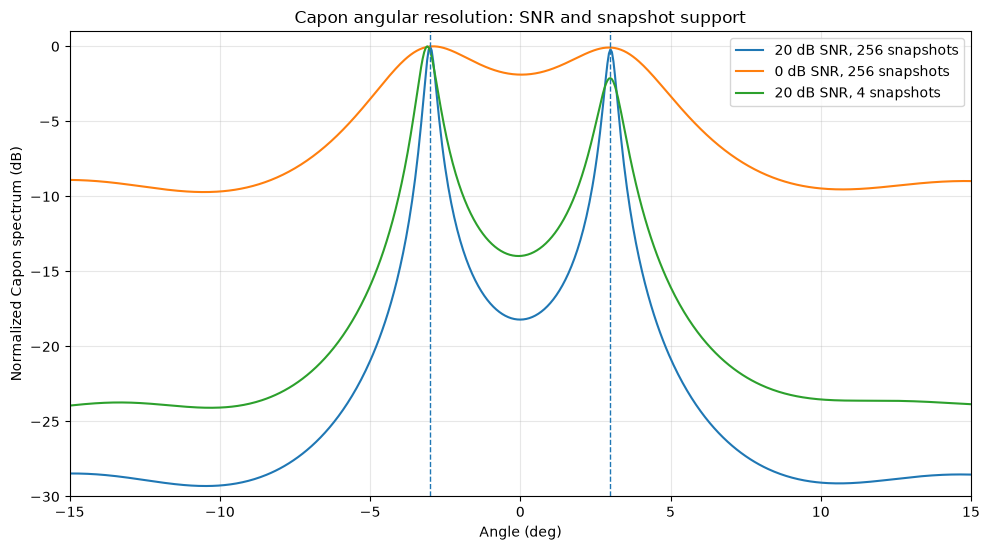

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Capon angular-resolution example
# ------------------------------------------------------------
M = 16
target_angles = [-3.0, 3.0]
angle_grid = np.linspace(-20, 20, 801)
m = np.arange(M)

def steering(theta):
    return np.exp(1j * np.pi * m * np.sin(np.deg2rad(theta)))

def capon_spectrum(snr_db, n_snapshots, seed=1):
    rng = np.random.default_rng(seed)

    A = np.column_stack([steering(t) for t in target_angles])
    S = (rng.standard_normal((2, n_snapshots))
         + 1j * rng.standard_normal((2, n_snapshots))) / np.sqrt(2)

    Xs = A @ S
    noise_power = np.mean(np.abs(Xs)**2) / 10**(snr_db / 10)
    X = Xs + np.sqrt(noise_power / 2) * (
        rng.standard_normal(Xs.shape) + 1j * rng.standard_normal(Xs.shape)
    )

    R = X @ X.conj().T / n_snapshots
    R += 1e-4 * np.trace(R).real / M * np.eye(M)
    R_inv = np.linalg.inv(R)

    P = np.array([
        1.0 / np.real(steering(t).conj() @ R_inv @ steering(t))
        for t in angle_grid
    ])

    return 10 * np.log10(P / P.max())

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 5.6))

plt.plot(angle_grid, capon_spectrum(20, 256),
         label="20 dB SNR, 256 snapshots")
plt.plot(angle_grid, capon_spectrum(0, 256),
         label="0 dB SNR, 256 snapshots")
plt.plot(angle_grid, capon_spectrum(20, 4),
         label="20 dB SNR, 4 snapshots")

for theta in target_angles:
    plt.axvline(theta, linestyle="--", linewidth=1)

plt.xlabel("Angle (deg)")
plt.ylabel("Normalized Capon spectrum (dB)")
plt.title("Capon angular resolution: SNR and snapshot support")
plt.xlim(-15, 15)
plt.ylim(-30, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

The high-SNR case with sufficient snapshot support produces two distinct Capon peaks close to the true target directions. This demonstrates the ability of the adaptive beamformer to resolve targets separated by less than the conventional beamwidth of the eight-element array.

Reducing the SNR weakens the spatial information contained in the covariance matrix, causing the two responses to broaden and eventually merge. Reducing the number of snapshots makes the covariance estimate less reliable, which can distort the peak shapes and amplitudes even when the SNR remains high.

Thus, Capon angular resolution is not determined by array aperture alone. Its practical resolution depends strongly on **SNR, snapshot support, and covariance-matrix quality**.

#### Model Mismatch

Capon/MVDR assumes that the steering vector used by the beamformer accurately represents the true array response. In practice, residual channel phase errors, gain mismatch, antenna-position errors, or imperfect calibration can introduce a mismatch between the measured data and the assumed array model.

The following simulation introduces controlled channel-phase errors into the received signals while Capon processing still uses the ideal steering vectors. This illustrates how increasing model mismatch can bias the estimated directions, distort the spatial spectrum, and reduce target separability.

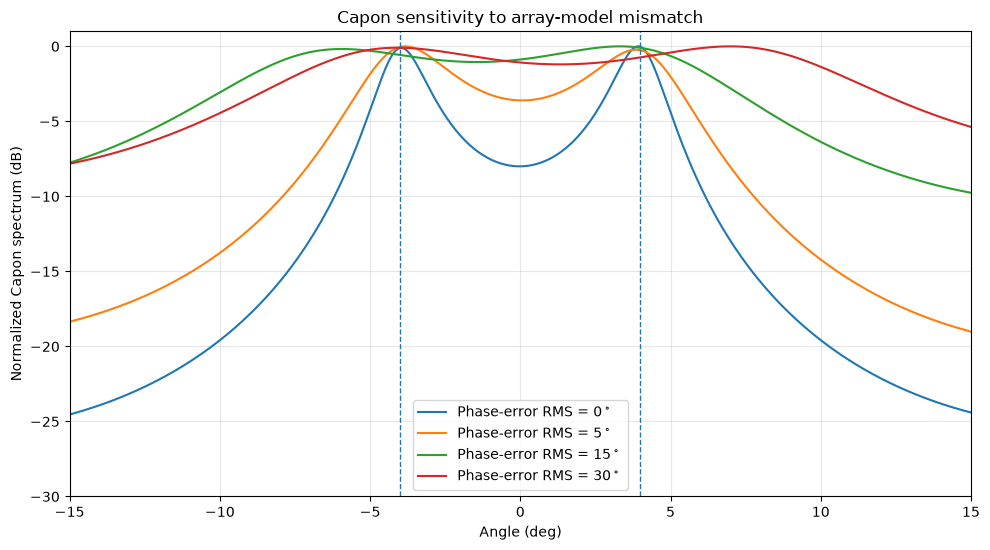

In [10]:
import numpy as np
import matplotlib.pyplot as plt

M = 8
target_angles = [-4.0, 4.0]
angle_grid = np.linspace(-20, 20, 801)
m = np.arange(M)
rng = np.random.default_rng(4)

def steering(theta):
    return np.exp(1j * np.pi * m * np.sin(np.deg2rad(theta)))

def capon_with_mismatch(phase_rms_deg):
    L, snr_db = 256, 20

    phase_err = np.deg2rad(
        rng.normal(0.0, phase_rms_deg, M)
    )
    D = np.diag(np.exp(1j * phase_err))

    A_true = np.column_stack(
        [D @ steering(t) for t in target_angles]
    )

    S = (rng.standard_normal((2, L))
         + 1j * rng.standard_normal((2, L))) / np.sqrt(2)

    Xs = A_true @ S
    noise_power = np.mean(np.abs(Xs)**2) / 10**(snr_db / 10)

    X = Xs + np.sqrt(noise_power / 2) * (
        rng.standard_normal(Xs.shape)
        + 1j * rng.standard_normal(Xs.shape)
    )

    R = X @ X.conj().T / L
    R += 1e-3 * np.trace(R).real / M * np.eye(M)
    R_inv = np.linalg.inv(R)

    P = np.array([
        1.0 / np.real(
            steering(t).conj() @ R_inv @ steering(t)
        )
        for t in angle_grid
    ])

    return 10 * np.log10(P / P.max())

plt.figure(figsize=(10, 5.6))

for phase_rms in [0, 5, 15, 30]:
    plt.plot(
        angle_grid,
        capon_with_mismatch(phase_rms),
        label=rf"Phase-error RMS = {phase_rms}$^\circ$"
    )

for theta in target_angles:
    plt.axvline(theta, linestyle="--", linewidth=1)

plt.xlabel("Angle (deg)")
plt.ylabel("Normalized Capon spectrum (dB)")
plt.title("Capon sensitivity to array-model mismatch")
plt.xlim(-15, 15)
plt.ylim(-30, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

The simulation shows that Capon/MVDR is highly sensitive to array-model mismatch. With an ideal steering model, the two closely spaced targets are clearly resolved and their peaks appear near the true directions.

As channel-phase mismatch increases, the Capon spectrum becomes progressively distorted: the peaks broaden, their amplitudes become asymmetric, and the estimated directions can shift away from the true target angles. For sufficiently large mismatch, the two-target structure may no longer be reliably resolved.

Thus, the super-resolution capability of Capon depends not only on SNR and snapshot support, but also on accurate array calibration and steering-vector modeling.